Isaac Noe

9/8/26

Lab 2 — Energy-Tracking Projectile

In [12]:
import numpy as np
import matplotlib.pyplot as plt

Part A — Add Energy Tracking (25 points)

In [13]:
# Part 1
# Defining the Function
def simulate_projectile_2d(v0, theta_deg, dt, m, g=9.81):

    # Initial conditions:
    angle = np.radians(theta_deg)
    x, y = 0.0, 0.0
    vx, vy = v0 * np.cos(angle), v0 * np.sin(angle)

    # Storage lists for plotting
    data = {'t': [0], 'x': [x], 'y': [y], 'vx': [vx], 'vy': [vy],
        'KE': [0.5*m*(vx**2+vy**2)], 'PE': [m*g*y], 'E': [0.5*m*(vx**2+vy**2)+m*g*y]}

    t = 0.0
    while y >= 0.0:
        # Compute acceleration (only gravity here)
        ax = 0.0
        ay = -g

        # Speed
        speed = np.sqrt(vx**2 + vy**2)

        # Update position (Euler)
        x = x + vx * dt
        y = y + vy * dt
        
        # Update velocity (Euler)
        vx = vx + ax * dt
        vy = vy + ay * dt

        t += dt

        # Energy tracking
        KE = 0.5 * m * (vx**2 + vy**2)
        PE = m * g * y
        E  = KE + PE
        
        data['t'].append(t)
        data['x'].append(x); data['y'].append(y)
        data['vx'].append(vx); data['vy'].append(vy)
        data['KE'].append(KE); data['PE'].append(PE); data['E'].append(E)
    return  data['t'], data['x'], data['y'], data['vx'], data['vy'], data['KE'], data['PE'], data['E']

In [14]:
# Part 2 Setting Conditions
t, x, y, vx, vy, ke, pe, e = simulate_projectile_2d(30, 50, 0.01, 1)

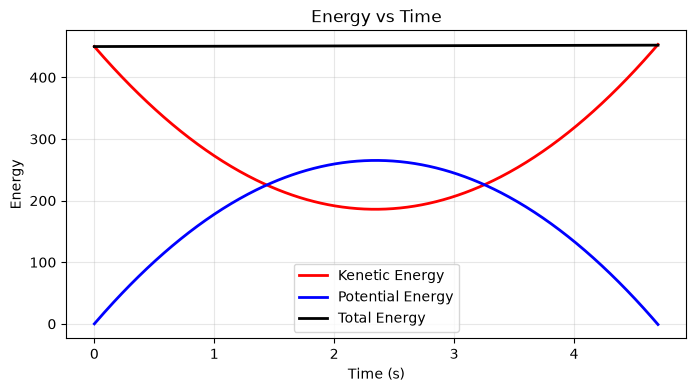

In [15]:
# Part 3
# Plotting Graph 1
plt.figure(figsize=(8, 4))
plt.plot(t, ke, color='red', linewidth=2, label="Kenetic Energy")
plt.plot(t, pe,color="blue", linewidth=2, label="Potential Energy")
plt.plot(t, e,color="black", linewidth=2, label="Total Energy")
plt.xlabel('Time (s)')
plt.ylabel('Energy')
plt.title('Energy vs Time')
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()

This graph shows the relationship of Kenetic, Potential, and Total Energy as a function of time.

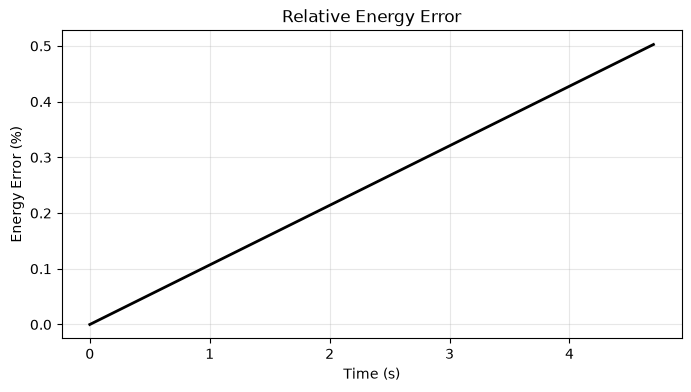

In [16]:
# Plotting Graph 2
E0 = e[0]
E_err = [(E - E0) / abs(E0) * 100 for E in e]
plt.figure(figsize=(8, 4))
plt.plot(t, E_err, color='black', linewidth=2)
plt.xlabel('Time (s)')
plt.ylabel('Energy Error (%)')
plt.title('Relative Energy Error')
plt.grid(True, alpha=0.3)
plt.show()

This graph shows energy drift as time progresses.

In [17]:
# Part 4
# Finding maximum absolute energy drift 
# and expressing it as a percentage of the initial energy
abs_e_drift = abs(e-e[0])
max_abs_e_drift = max(abs_e_drift)
print(f'The maximum absolute energy drift over the flight is {max_abs_e_drift:.3}')
print(f'and it as a percentage of the initial energy is {(max_abs_e_drift/e[0])*100:.3}%')

The maximum absolute energy drift over the flight is 2.26
and it as a percentage of the initial energy is 0.503%


✎ Interpret it: With standard Euler, you should see E total slowly grow over the flight — the simulation invents energy from nothing. In 2–3 sentences, explain what you observe. Is the drift steady, or does it accelerate? Roughly what percentage of the initial energy is gained by the time the projectile lands?

The energy drift is steady, and when the projectile lands roughly 0.503% of the initial energy is gained.

Part B — Euler vs. Euler-Cromer (35 points)

In [18]:
# Part 1
# Defining the function
def simulate(method, dt, v0, angle_deg, g=9.81, m=1):
    """Simulate projectile with energy tracking.
    method: 'euler' or 'euler-cromer'
    """
    angle = np.radians(angle_deg)
    x, y = 0.0, 0.0
    vx, vy = v0 * np.cos(angle), v0 * np.sin(angle)

    # Storage lists for plotting
    data = {'t': [0], 'x': [x], 'y': [y], 'vx': [vx], 'vy': [vy],
        'KE': [0.5*m*(vx**2+vy**2)], 'PE': [m*g*y], 'E': [0.5*m*(vx**2+vy**2)+m*g*y]}
    t = 0.0

    while t < 10.0 and y >= 0:
        ax, ay = 0.0, -g

        if method == 'euler':
            x  += vx * dt        # position uses OLD velocity
            y  += vy * dt
            vx += ax * dt
            vy += ay * dt
        elif method == 'euler-cromer':
            vx += ax * dt        # velocity updated FIRST
            vy += ay * dt
            x  += vx * dt        # position uses NEW velocity
            y  += vy * dt

        t += dt
        # Energy tracking

        KE = 0.5 * m * (vx**2 + vy**2)
        PE = m * g * y
        E  = KE + PE

        data['t'].append(t)
        data['x'].append(x); data['y'].append(y)
        data['vx'].append(vx); data['vy'].append(vy)
        data['KE'].append(KE); data['PE'].append(PE); data['E'].append(E)
    return  data['t'], data['x'], data['y'], data['vx'], data['vy'], data['KE'], data['PE'], data['E']

In [19]:
# Part 2
# Running both methods
te, xe, ye, vxe, vye, kee, pee, ee = simulate('euler', 0.01, 30, 50, 9.81, 1)
tc, xc, yc, vxc, vyc, kec, pec, ec = simulate('euler-cromer', 0.01, 30, 50, 9.81, 1)

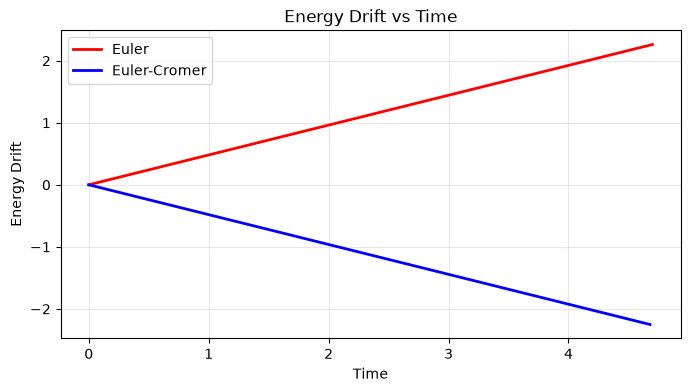

In [20]:
# Part 3
# Plotting the Graph
plt.figure(figsize=(8, 4))
plt.plot(te, ee-ee[0], color='red',label='Euler', linewidth=2)
plt.plot(tc, ec-ec[0], color='blue',label='Euler-Cromer', linewidth=2)
plt.xlabel('Time')
plt.ylabel('Energy Drift')
plt.title('Energy Drift vs Time')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

This graph show the energy drift of both euler and euler-cromer as a funtion of time.

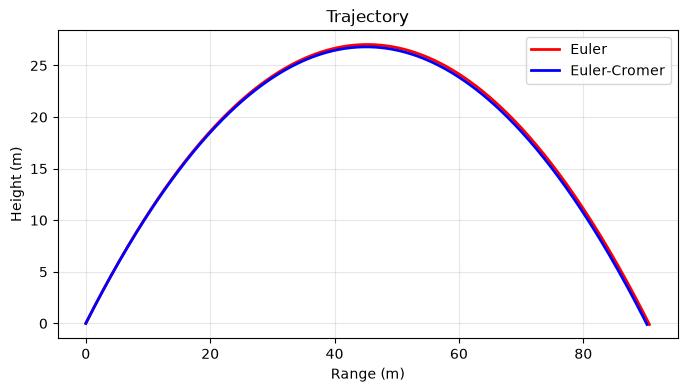

In [21]:
# Part 4
# Plotting the Other Graph
plt.figure(figsize=(8, 4))
plt.plot(xe, ye, color='red',label='Euler', linewidth=2)
plt.plot(xc, yc, color='blue',label='Euler-Cromer', linewidth=2)
plt.xlabel('Range (m)')
plt.ylabel('Height (m)')
plt.title('Trajectory')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

This graph show the trajectories of both the Euler method and the Euler-Cromer method.

Compare the trajectories: Are they visibly different? Report the difference in landing range between the two methods.

They are visibly different. The Euler-Cromer line does not go as far as the Euler line.

✎ Explain it: Both methods use the same step size and the same physics. In 3–4 sentences, explain why simply reordering two lines produces such different energy behavior. (Hint: think about which velocity — old or new — is used to move the position, and whether that tends to over- or under-shoot.)

The Euler method uses the old velocity to update position and it tends to over-shoot. The Euler-Cromer method uses the new velocity to update the postition and it tends to under-shoot. The way the Euler method is set up makes it add energy to the system and the way the Euler-Cromer method is setup makes it take away energy from the system.

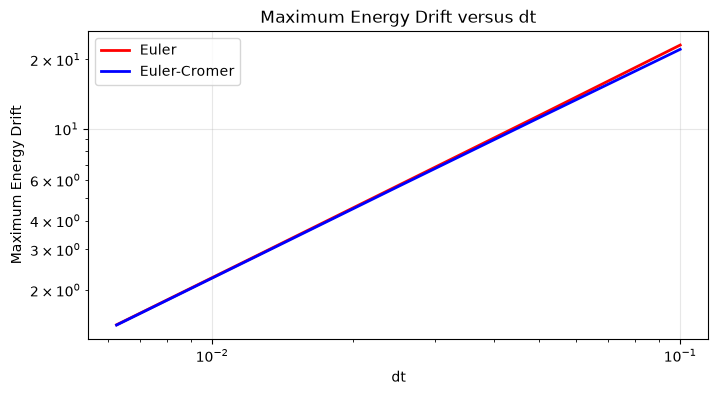

The slope of the Euler line is 1.01
The slope of the Euler-Cromer line is 0.99


In [22]:
# Setting Constans

dt_list = [0.1, 0.05, 0.025, 0.0125, 0.00625]
e_energy_list = []
ec_energy_list = []
run = len(dt_list)
start = 0
end = 0

# Finding max energy drift for euler
while start != run:
    te, xe, ye, vxe, vye, kee, pee, ee = simulate('euler', dt_list[start], 30, 50, 9.81, 1)

    abs_e_drift = abs(ee-ee[0])
    max_abs_e_drift = max(abs_e_drift)
    
    e_energy_list.append(max_abs_e_drift)

    start += 1

# Finding max energy drift for euler-cromer
while end != run:
    tc, xc, yc, vxc, vyc, kec, pec, ec = simulate('euler-cromer', dt_list[end], 30, 50, 9.81, 1)
    
    abs_ec_drift = abs(ec-ec[0])
    max_abs_ec_drift = max(abs_ec_drift)
    
    ec_energy_list.append(max_abs_ec_drift)

    end += 1

# Finding the Slope of the Lines
e_slope = np.polyfit(np.log(dt_list), np.log(e_energy_list), 1)[0]
ec_slope = np.polyfit(np.log(dt_list), np.log(ec_energy_list), 1)[0]

#Ploting the Graphs
plt.figure(figsize=(8, 4))
plt.loglog(dt_list, e_energy_list, color='red',label='Euler', linewidth=2)
plt.loglog(dt_list, ec_energy_list, color='blue',label='Euler-Cromer', linewidth=2)
plt.xlabel('dt')
plt.ylabel('Maximum Energy Drift')
plt.title('Maximum Energy Drift versus dt')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

print(f'The slope of the Euler line is {e_slope:.2f}')
print(f'The slope of the Euler-Cromer line is {ec_slope:.2f}')

This graph shows that as the dt increases so does the maximum energy drift.

The slope of the Euler line was 1.01 and the slope of the Euler-Cromer line was 0.99. This shows that as dt is halfed for Euler the error is almosted halfed. The reason it is almost halfed is because the slope is slightly above 1 so the error is lowered slighlty quicker. Similarly to Euler, the Euler-Cromer slope is almost halfed but because it's slope is slightly under 1 the error is lowered slighly slower.

✎ Analyze it: Answer in a Markdown cell:
1. What is the measured order p of standard Euler for energy drift? Does it match what the Week 2 lesson predicted?

The measured order of p of standard Euler for energy drift was 1.01. It does not match the 1.00 that the Week 2 lesson predicted.

2. How does Euler-Cromer's convergence curve compare? Is its energy drift smaller at every step size you tested?

The measured order of p of standard Euler-Cromer for energy drift was 0.99, and its energy drift was smaller at every step size tested.

3. If you needed the energy conserved to within 0.01%, which method and roughly what step size would you choose? Justify with your data.

I would use a step size of 0.00625 and I would use the Euler method because it appears to be lowering the error better.